In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df['Target'] = df['Attrition'].map({
    'Yes': 0,   # Dropped
    'No': 1     # Completed
})

In [7]:
features = [
    'JobInvolvement',
    'PerformanceRating',
    'EnvironmentSatisfaction',
    'TrainingTimesLastYear'
]

X = df[features]
y = df['Target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8537414965986394
              precision    recall  f1-score   support

           0       0.36      0.13      0.19        39
           1       0.88      0.96      0.92       255

    accuracy                           0.85       294
   macro avg       0.62      0.55      0.55       294
weighted avg       0.81      0.85      0.82       294



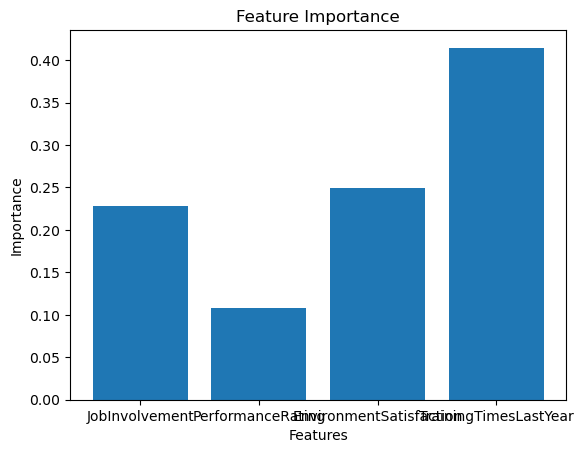

In [17]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [29]:
new_intern = pd.DataFrame([[3, 4, 3, 2]], columns=[
    'JobInvolvement',
    'PerformanceRating',
    'EnvironmentSatisfaction',
    'TrainingTimesLastYear'
])

prediction = model.predict(new_intern)

if prediction[0] == 2:
    print("Likely to COMPLETE internship")
else:
    print("Likely to DROP OUT")

Likely to DROP OUT


In [31]:
print(model.predict_proba(new_intern))

[[0.1862574 0.8137426]]
